In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as mpl
mpl.rcParams["mathtext.fontset"] = 'cm'
mpl.rcParams["font.size"] = 13
mpl.rcParams["figure.autolayout"] = True

In [ ]:
# Load lgo predictions

path = '../../data/lgo_models/'
df = pd.read_csv(path + 'lgo_predict_allpredictions_.csv')

In [3]:
# Check test preditions

test = df[df['Phage'] == df['phage']]
if not all(test['dataset'] == 'test'):
    raise NameError()
if len(test) != len(df[df['dataset'] == 'test']):
    raise NameError()

dfTest = pd.read_csv(path + 'lgo_predict_testpredictions_.csv')
test.index = range(len(test))
if not (test == dfTest).all().all():
    raise NameError()

In [4]:
# FP, FN, TP, TN

phages = dfTest['Phage'].unique()
phages.sort()
stats = pd.DataFrame(columns=['phage', 'False_positives', 'False_negatives', 
                              'True_positives', 'True_negatives'])

for ph in phages:
    relevant_elements = dfTest[dfTest['Phage'] == ph]['observed'] < 60
    retrieved_elements = dfTest[dfTest['Phage'] == ph]['predicted'] < 60
    fp = (retrieved_elements & ~relevant_elements).sum()
    fn = (relevant_elements & ~retrieved_elements).sum()
    tp = (retrieved_elements & relevant_elements).sum()
    tn = (~retrieved_elements & ~relevant_elements).sum()
    stats.loc[len(stats)] = [ph, fp, fn, tp, tn]


In [5]:
# Calcular F1, precision, recall:

stats['precision'] = stats['True_positives'] / (stats['True_positives'] + stats['False_positives'])
stats['recall'] = stats['True_positives'] / (stats['True_positives'] + stats['False_negatives'])
stats['F1'] = 2 / (stats['recall']**-1 + stats['precision']**-1)

In [6]:
# Calcular activity:

stats['Activity'] = (stats['True_positives'] + stats['False_negatives']) / 301

# if not (abs(stats['Activity'] - dfStats['Activity']) < 1e-15).all():
#     raise NameError()

In [7]:
# Calcular RMSE:
stats['RMSE'] = None

for ph in phages:
    error = dfTest[dfTest['Phage'] == ph]['observed'] - dfTest[dfTest['Phage'] == ph]['predicted']
    sqError = error**2
    stats.loc[stats['phage'] == ph, 'RMSE'] = sqError.mean()**.5

# if not (abs(stats['RMSE'] - dfStats['Testing.RMSE']) < 1e-13).all():
#     raise NameError

In [ ]:
# Build phage pangenome to plot with comparison between models

# Load pangenomes
interaction_data = pd.read_csv('../../data/training_data.tsv', delimiter='\t')

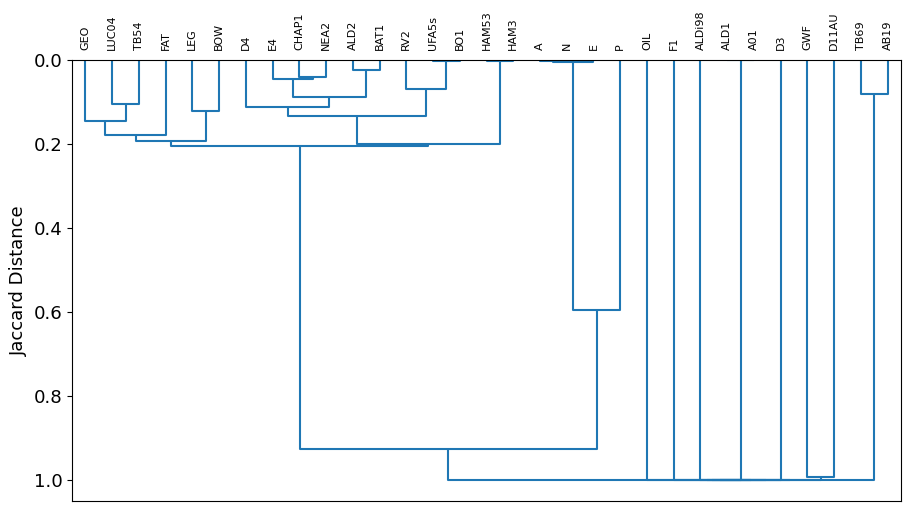

In [10]:
# Tree

rows = interaction_data.index.str.startswith('CAN01_')
cols = interaction_data.columns.str.endswith('_phage')
phage_pangenome = interaction_data.iloc[rows, cols]

metric = 'jaccard'

px = 1/plt.rcParams['figure.dpi']

# Hierarchical clustering (average linkage = good default)
Z = linkage(phage_pangenome, method='average', metric=metric, optimal_ordering=True)

# Plot dendrogram
plt.figure(0, figsize=(930*px, 530*px))
fig, ax = plt.subplots(num=0)

dendrogram(Z, labels=[l[6:] for l in phage_pangenome.index], leaf_rotation=90, color_threshold=0, orientation='bottom')
plt.ylabel("Jaccard Distance")
plt.tight_layout()

0.00047


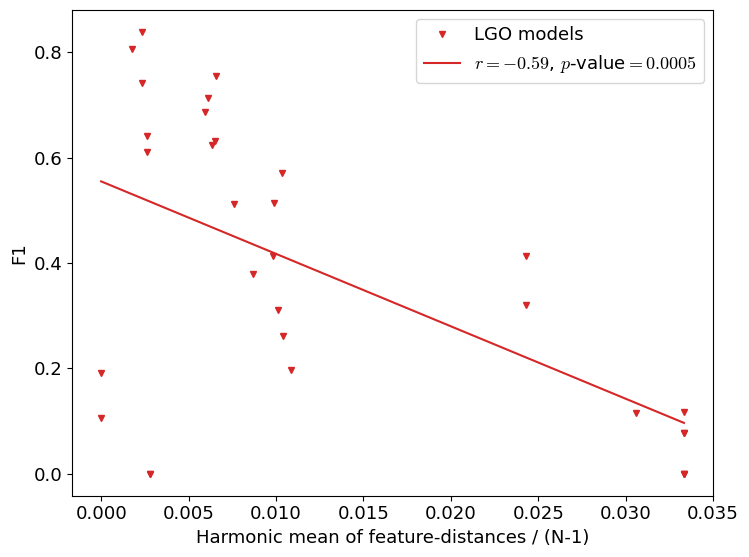

In [ ]:
# Plot F1 vs Feature Distance:

feature_distances = pd.read_csv('../../data/feature_distances.csv', index_col='phage')
feature_distances.sort_values('IMID', axis=0, inplace=True)
fagos = feature_distances.index.values
distance = feature_distances['IMID'].values / 30
F1 = np.array([stats[stats['phage'] == ph]['F1'].values[0] for ph in fagos])

# Linear regression:
fit = np.polyfit(distance, F1, 1)
r = pearsonr(distance, F1).statistic
xFit = np.array([distance[0], distance[-1]])

# p-value:
seed = 205752514047359153479908198032686232234
rng = np.random.default_rng(seed=seed)
r_perm = []
for l in range(100000):
    permuted_data = rng.permuted(F1, axis=0)
    r_perm += [pearsonr(distance, permuted_data).statistic]
r_perm = np.array(r_perm)
p = (abs(r_perm) >= abs(r)).sum() / len(r_perm)

fig, ax = plt.subplots(figsize=np.array([6.4, 4.8])*1.2)
ms = 5
ax.set_xlabel('Harmonic mean of feature-distances / (N-1)')
ax.set_ylabel('F1')


label = fr'$r={np.around(r, 2)}$, $p$-value$={np.around(p,4)}$'
ax.plot(distance, F1, 'v', ms=ms, c='C3', label=['LGO models'])
ax.plot(xFit, fit[0]*xFit + fit[1], c='C3', alpha=1, label=label)

ax.legend(fontsize=13)

print(p)

path = '../../Alison Low\'s files - Pan_Phage ML manuscript/figures/fig4a.png'
# fig.savefig(path, dpi=300)

/opt/miniconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


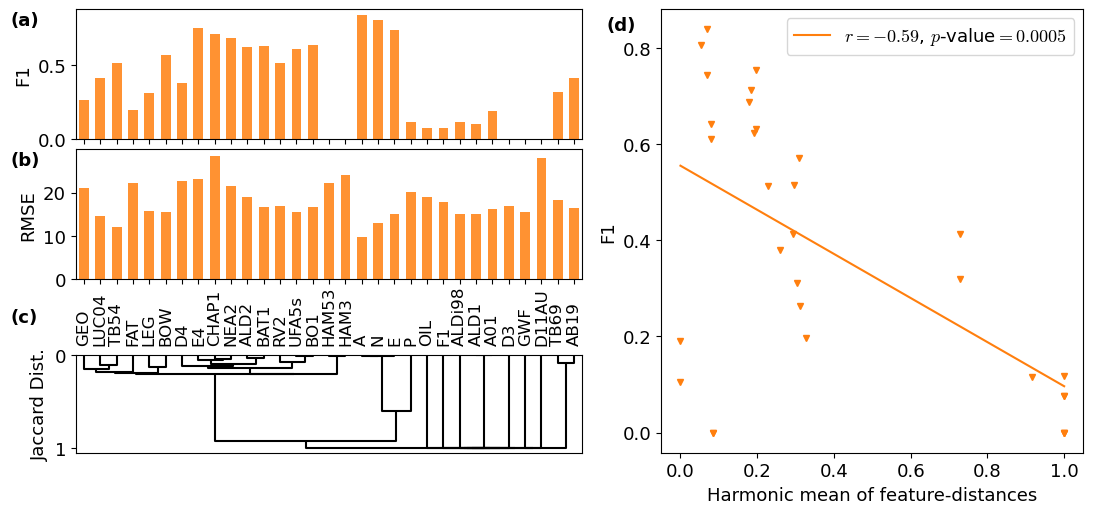

In [ ]:
# Fig 4:

from matplotlib.gridspec import GridSpec

# Create the figure
fig = plt.figure(figsize=(13, 11.52 * .5))

# Define the grid: 3 rows, 2 columns
# width_ratios: [Left Column Width, Right Column Width]
# height_ratios: [Top Row Height, Middle Row Height, Bottom Row Height]
gs = GridSpec(4, 2, figure=fig, 
              width_ratios=[3, 2.5],       # Left is twice as wide as right
              height_ratios=[2, 2, .85, 1.5],   # All three rows on left are equal height
              hspace=0.1,                # Vertical space between rows
              wspace=0.17)                # Horizontal space between columns

# Create the 3 axes on the left (Column 0)
ax1 = fig.add_subplot(gs[0, 0]) # Top Left
ax1.tick_params(labelbottom=False) 
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1) # Middle Left
ax2.tick_params(labelbottom=False) 
ax3 = fig.add_subplot(gs[3, 0], sharex=ax1) # Bottom Left

# Create the 1 axis on the right (Column 1)
# The slice ':' means it spans all rows in that column
ax4 = fig.add_subplot(gs[:, 1]) 

dendrogram(Z, labels=[l[6:] for l in phage_pangenome.index], leaf_rotation=90, 
           color_threshold=0, orientation='bottom', ax=ax3, leaf_font_size=12,
           above_threshold_color='k')

fagos = ax3.get_xticklabels()
w = 3

for i in range(len(fagos)):
    x = fagos[i].get_position()[0]
    y = stats[stats['phage'] == fagos[i].get_text()]['F1']
    bar1 = ax1.bar(x, y, width=2*w, color='C1', alpha=.85)#, hatch='\\\\')
    y = stats[stats['phage'] == fagos[i].get_text()]['RMSE']
    bar2 = ax2.bar(x, y, width=2*w, color='C1', alpha=.85)#, hatch='\\\\')

feature_distances = pd.read_csv('../../data/feature_distances.csv', index_col='phage')
feature_distances.sort_values('IMID', axis=0, inplace=True)
fagos = feature_distances.index.values
distance = feature_distances['IMID'].values
F1 = np.array([stats[stats['phage'] == ph]['F1'].values[0] for ph in fagos])

# Linear regression:
fit = np.polyfit(distance, F1, 1)
r = pearsonr(distance, F1).statistic
xFit = np.array([distance[0], distance[-1]])

ms = 5
ax4.set_xlabel('Harmonic mean of feature-distances')
ax4.set_ylabel('F1')

label = fr'$r={np.around(r, 2)}$, $p$-value$={np.around(p,4)}$'
ax4.plot(distance, F1, 'v', ms=ms, c='C1')
ax4.plot(xFit, fit[0]*xFit + fit[1], c='C1', alpha=1, label=label)

ax4.legend(fontsize=13)

ax1.set_ylabel('F1')
ax2.set_ylabel('RMSE')
ax3.set_ylabel('Jaccard Dist.')

for axis, label in zip([ax1, ax2, ax3, ax4], ['(a)', '(b)', '(c)', '(d)']):
    offset = 0
    if label == '(c)':
        offset = .5
    axis.text(-0.13, .985 + offset, label,
              transform=axis.transAxes,
              va='top', ha='left',
              fontweight='bold')

path = '../../Alison Low\'s files - Pan_Phage ML manuscript/figures/Fig 4_combined.png'
# fig.savefig(path, dpi=300, bbox_inches='tight')